## Titanic (kaggle)

In [10]:
import sys
from pathlib import Path

In [11]:
sys.path.append(str(Path().resolve().parent))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from src.features import FeatureEngineer
from src.utils import draw_phik_matrix

from configs import config

%matplotlib inline
%load_ext autoreload 
%autoreload 2

### EDA

In [16]:
config.paths.path_to_train_data

PosixPath('/Users/ruslan/ML experiiment VADIM/Titanic(kaggle)/data/train.csv')

In [47]:
df = pd.read_csv(config.paths.path_to_train_data)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
report = sv.analyze(df)
report.show_html("df_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report df_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [19]:
df[df['Fare']==0].shape

(15, 12)

Выводы:
- survived не сбалансирован, надо использовать стратификацию
- passanger_id не несет информацию - удалить
- необходимо заполнить пропуски в age(20%) и embarked (<1%), безлайн - заполнить медианой и частым
- ticket текстовый возможно номер несет информацию, инициалы возможно несут информацию
- cabin текстовый, надо вытащить класс и номер кабины
- name может можно будет вытащить статус


In [58]:

from src.features import FeatureEngineer
fe = FeatureEngineer()
df_fe = fe.fit_transform(df)
df_fe.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,Family,Is_alone,Big_family,Title,Fare_per_person,Age_class,Fare_class,Name_length,Fare_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,1,0,0,Mr,3.62500,66.0,21.7500,23,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,1,0,0,Mrs,35.64165,38.0,71.2833,51,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,0,1,0,Miss,7.92500,78.0,23.7750,22,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,1,0,0,Mrs,26.55000,35.0,53.1000,44,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,0,1,0,Mr,8.05000,105.0,24.1500,24,2.202765


In [23]:
report = sv.analyze(df_fe)
report.show_html("df_fe_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:05 -> (00:00 left)


Report df_fe_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [31]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    str    
 4   Sex              891 non-null    str    
 5   Age              891 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    str    
 9   Fare             891 non-null    float64
 10  Cabin            891 non-null    str    
 11  Embarked         891 non-null    str    
 12  Family           891 non-null    int64  
 13  Is_alone         891 non-null    int64  
 14  Big_family       891 non-null    int64  
 15  Title            891 non-null    str    
 16  Fare_per_person  891 non-null    float64
 17  Age_class        891 non-nu

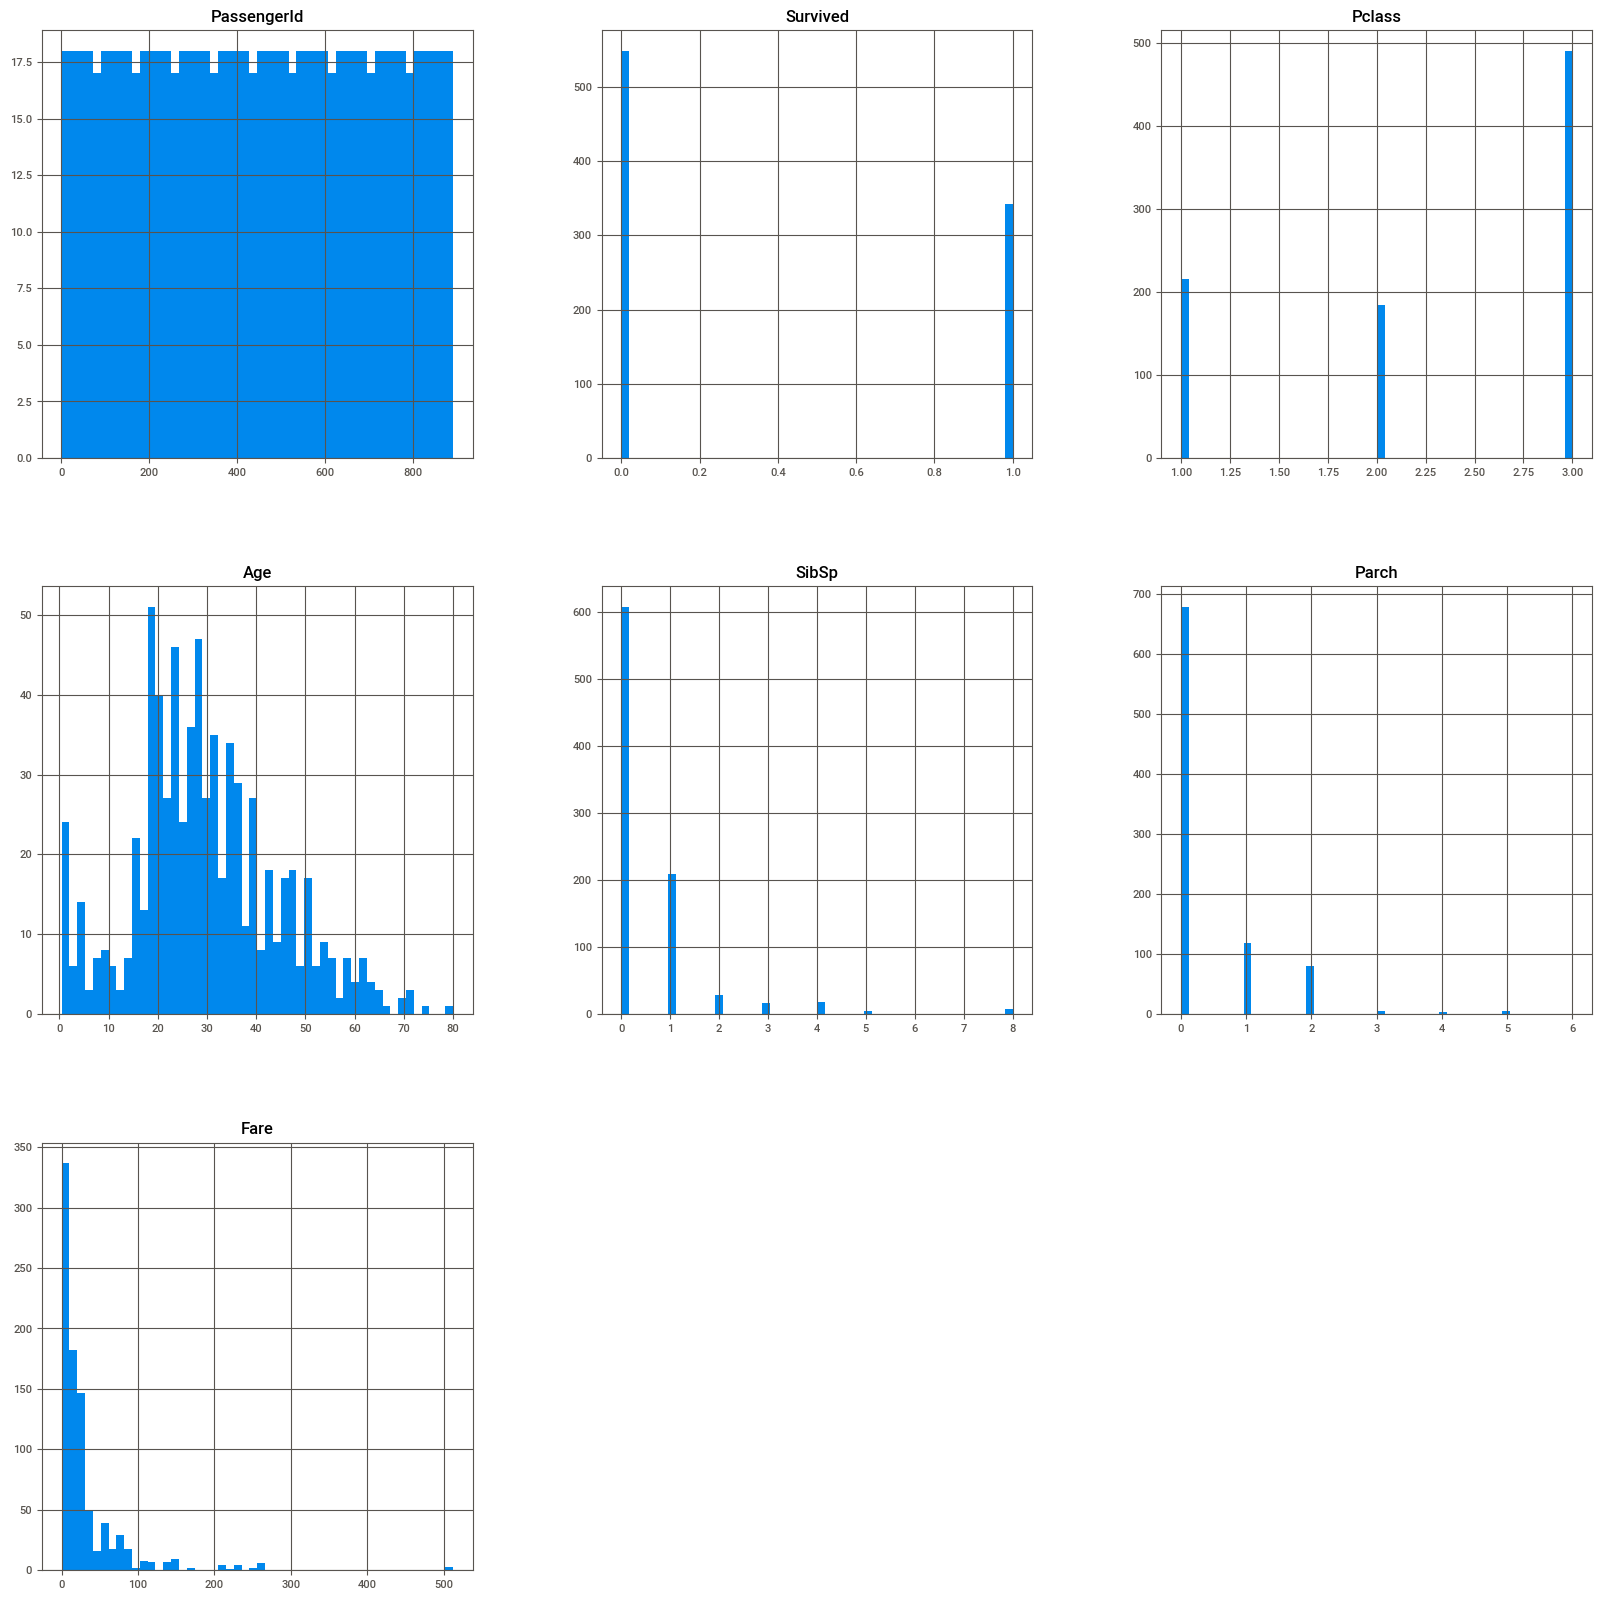

In [55]:
num_columns =  df.select_dtypes(include='number').columns.tolist()
df[num_columns].hist(bins=50, figsize=(20, 20));

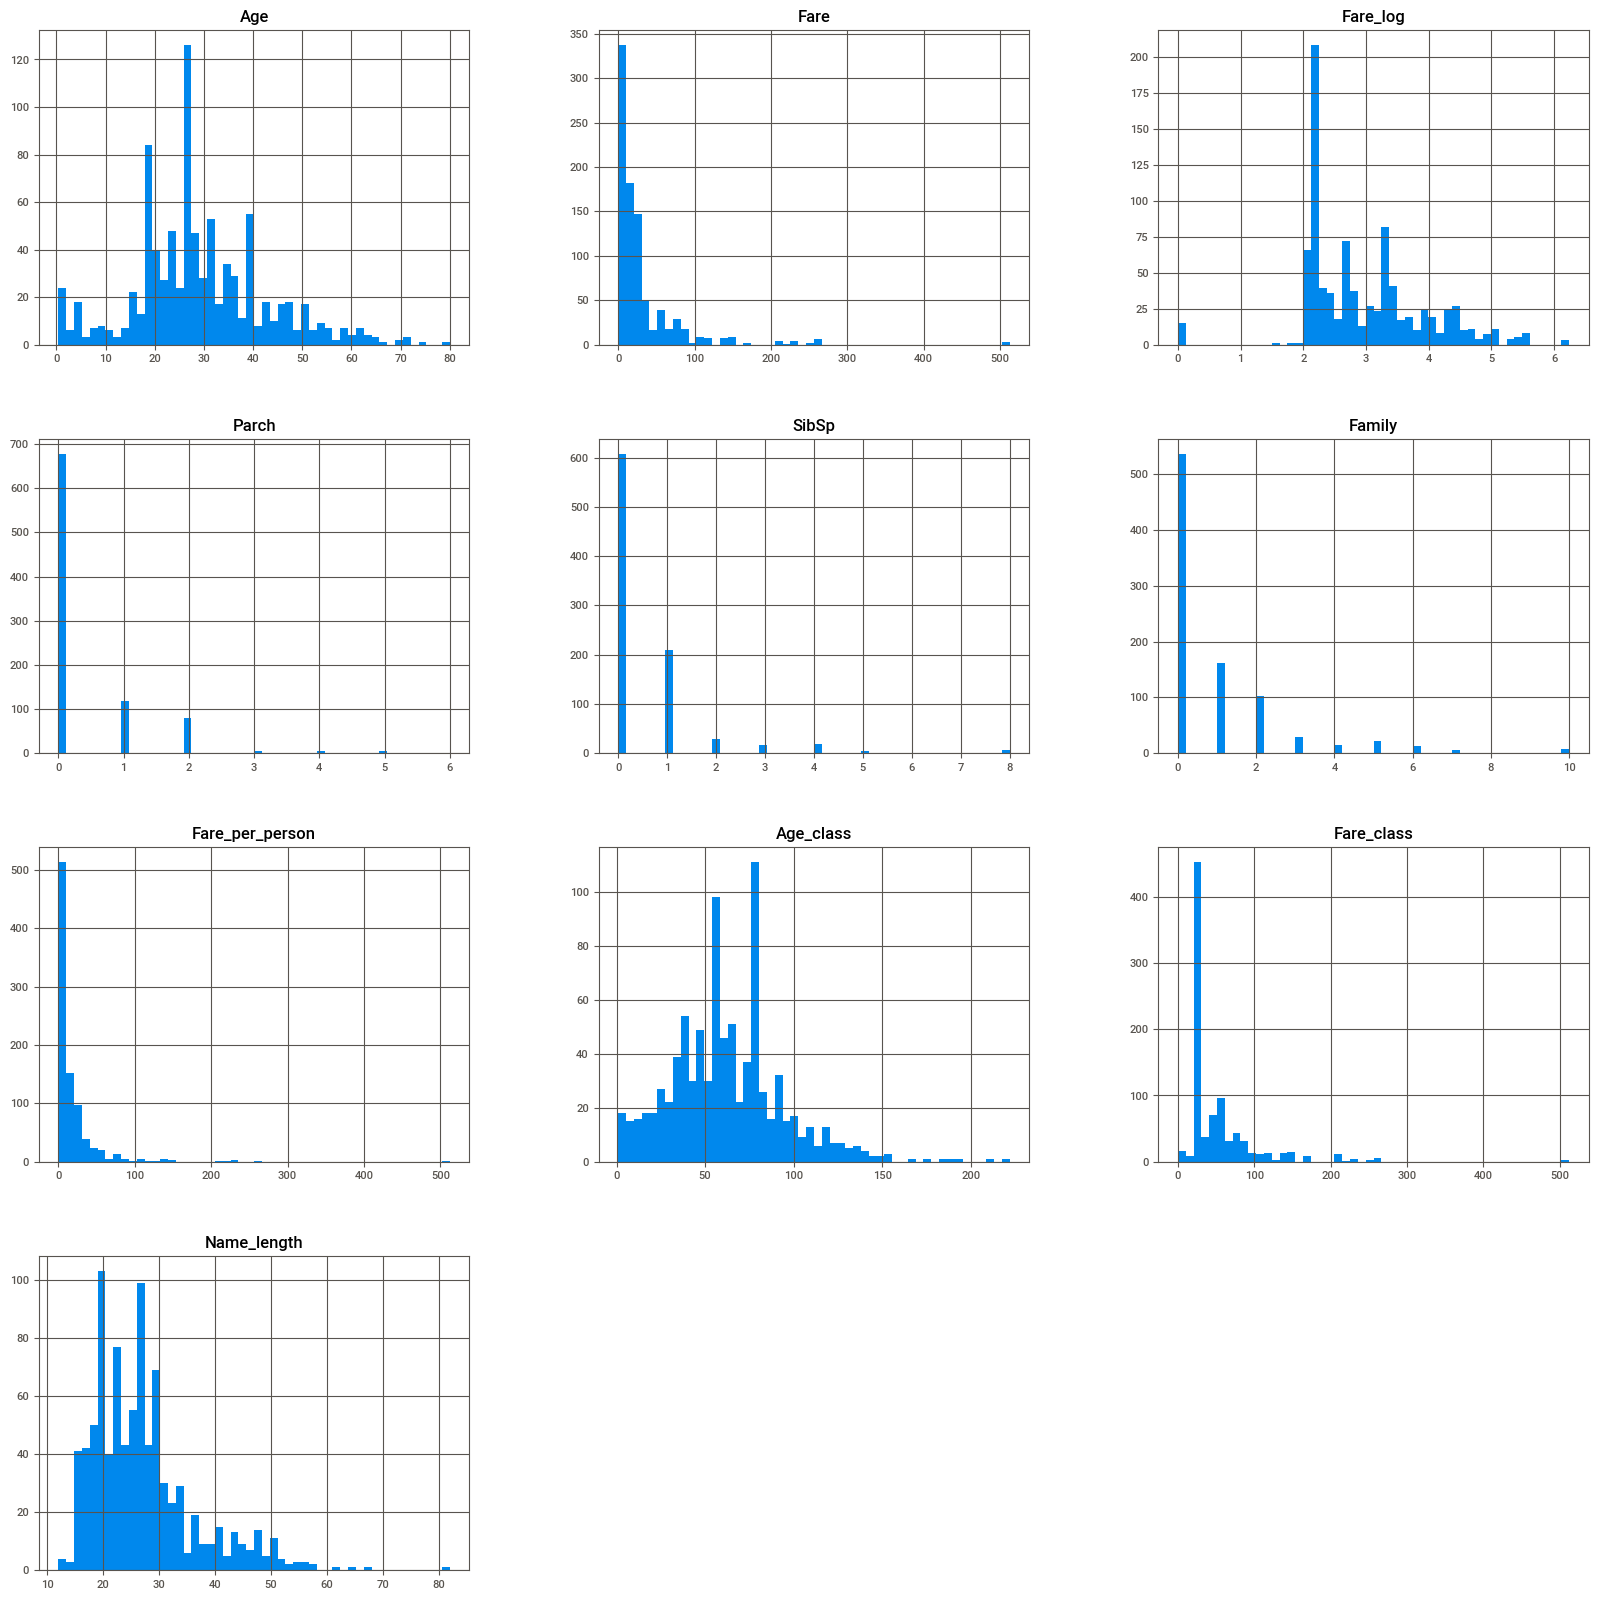

In [59]:
from src.features import get_feature_groups
FORCE_CATEGORICAL, FORCE_ORDINAL, FORCE_NUMERICAL = get_feature_groups()

# num_columns =  df_fe.select_dtypes(include='number').columns.tolist()
df_fe[FORCE_NUMERICAL].hist(bins=50, figsize=(20, 20));

In [ ]:

def scatter_plt(hue):
    val_columns_ = FORCE_NUMERICAL
    num_plots = len(val_columns_)

    # Создаем один ряд с num_plots подграфиками
    fig, axes = plt.subplots(1, num_plots, figsize=(num_plots * 4, 4))

    for i, col in enumerate(val_columns_):
        sns.scatterplot(data=df_fe, x=col, y='Survived', hue=hue, ax=axes[i])
        axes[i].set_title(f'Survived vs {col}')

    # Подгонка расстояния между графиками
    fig.suptitle('Диаграммма рассеяния  Survived с количественными признаками с учетом ' + hue)
    plt.tight_layout()
    plt.show()

for col in FORCE_CATEGORICAL:
    scatter_plt(col)

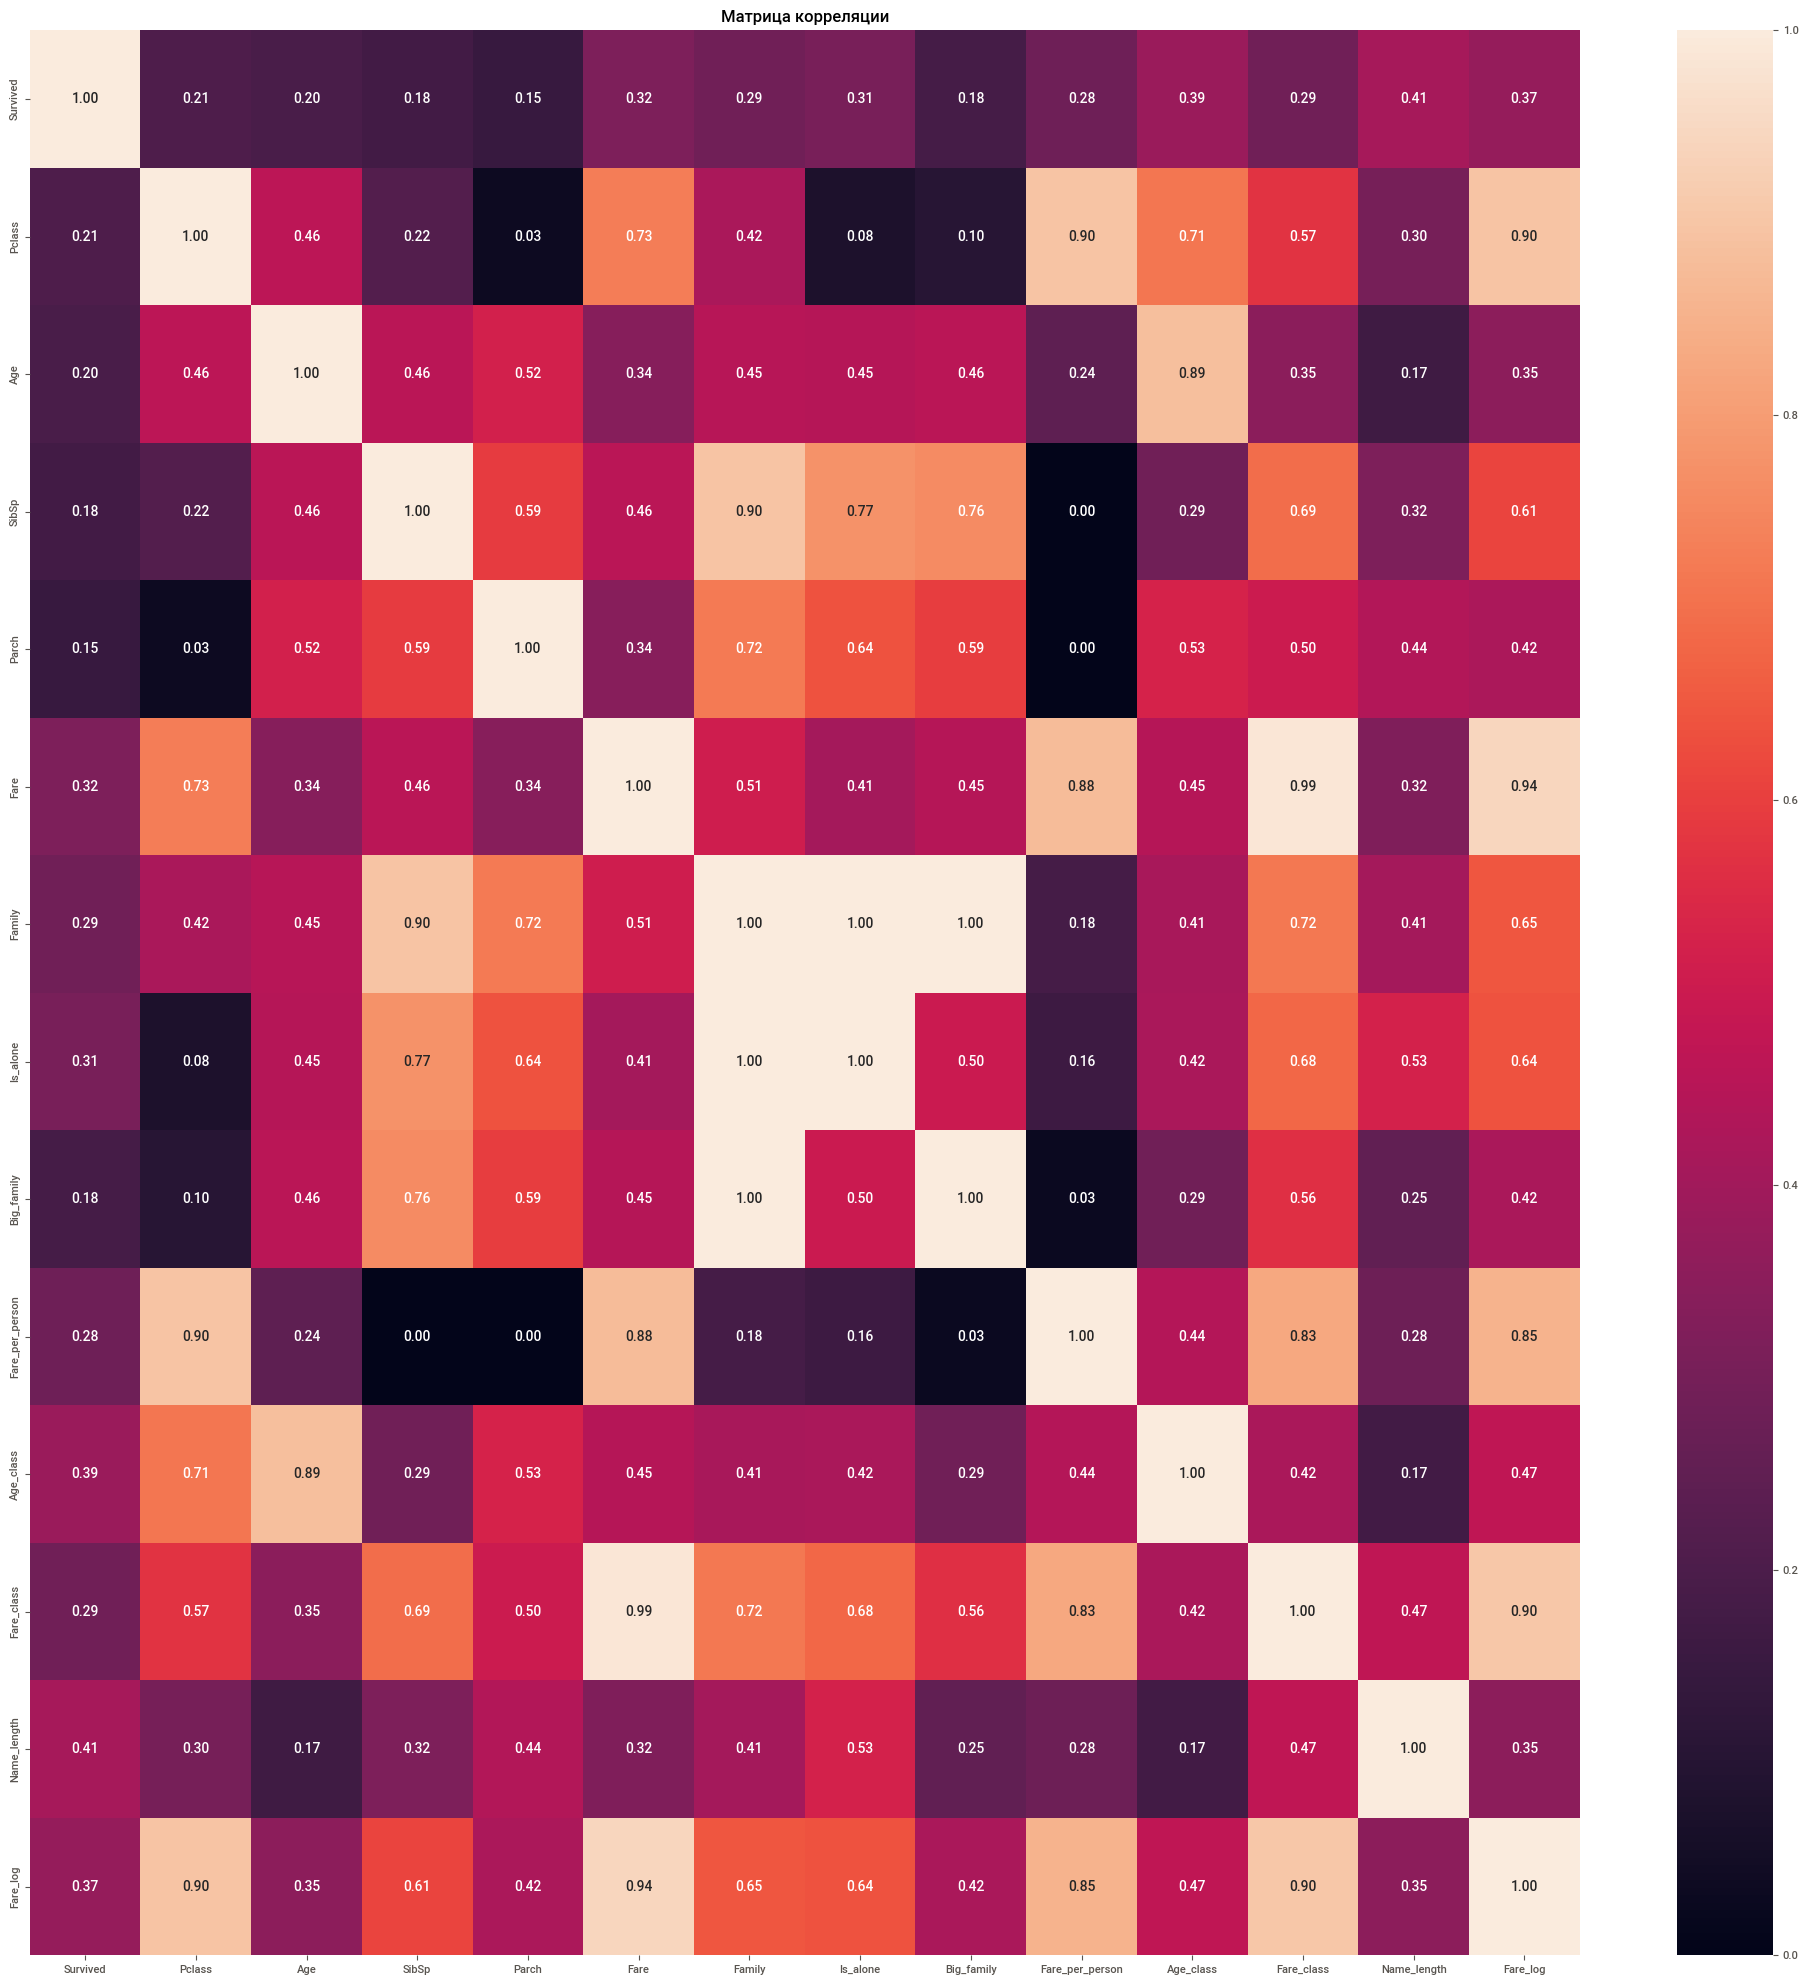

In [39]:
from src.utils import draw_phik_matrix
draw_phik_matrix(df_fe, drop_columns=['PassengerId'])


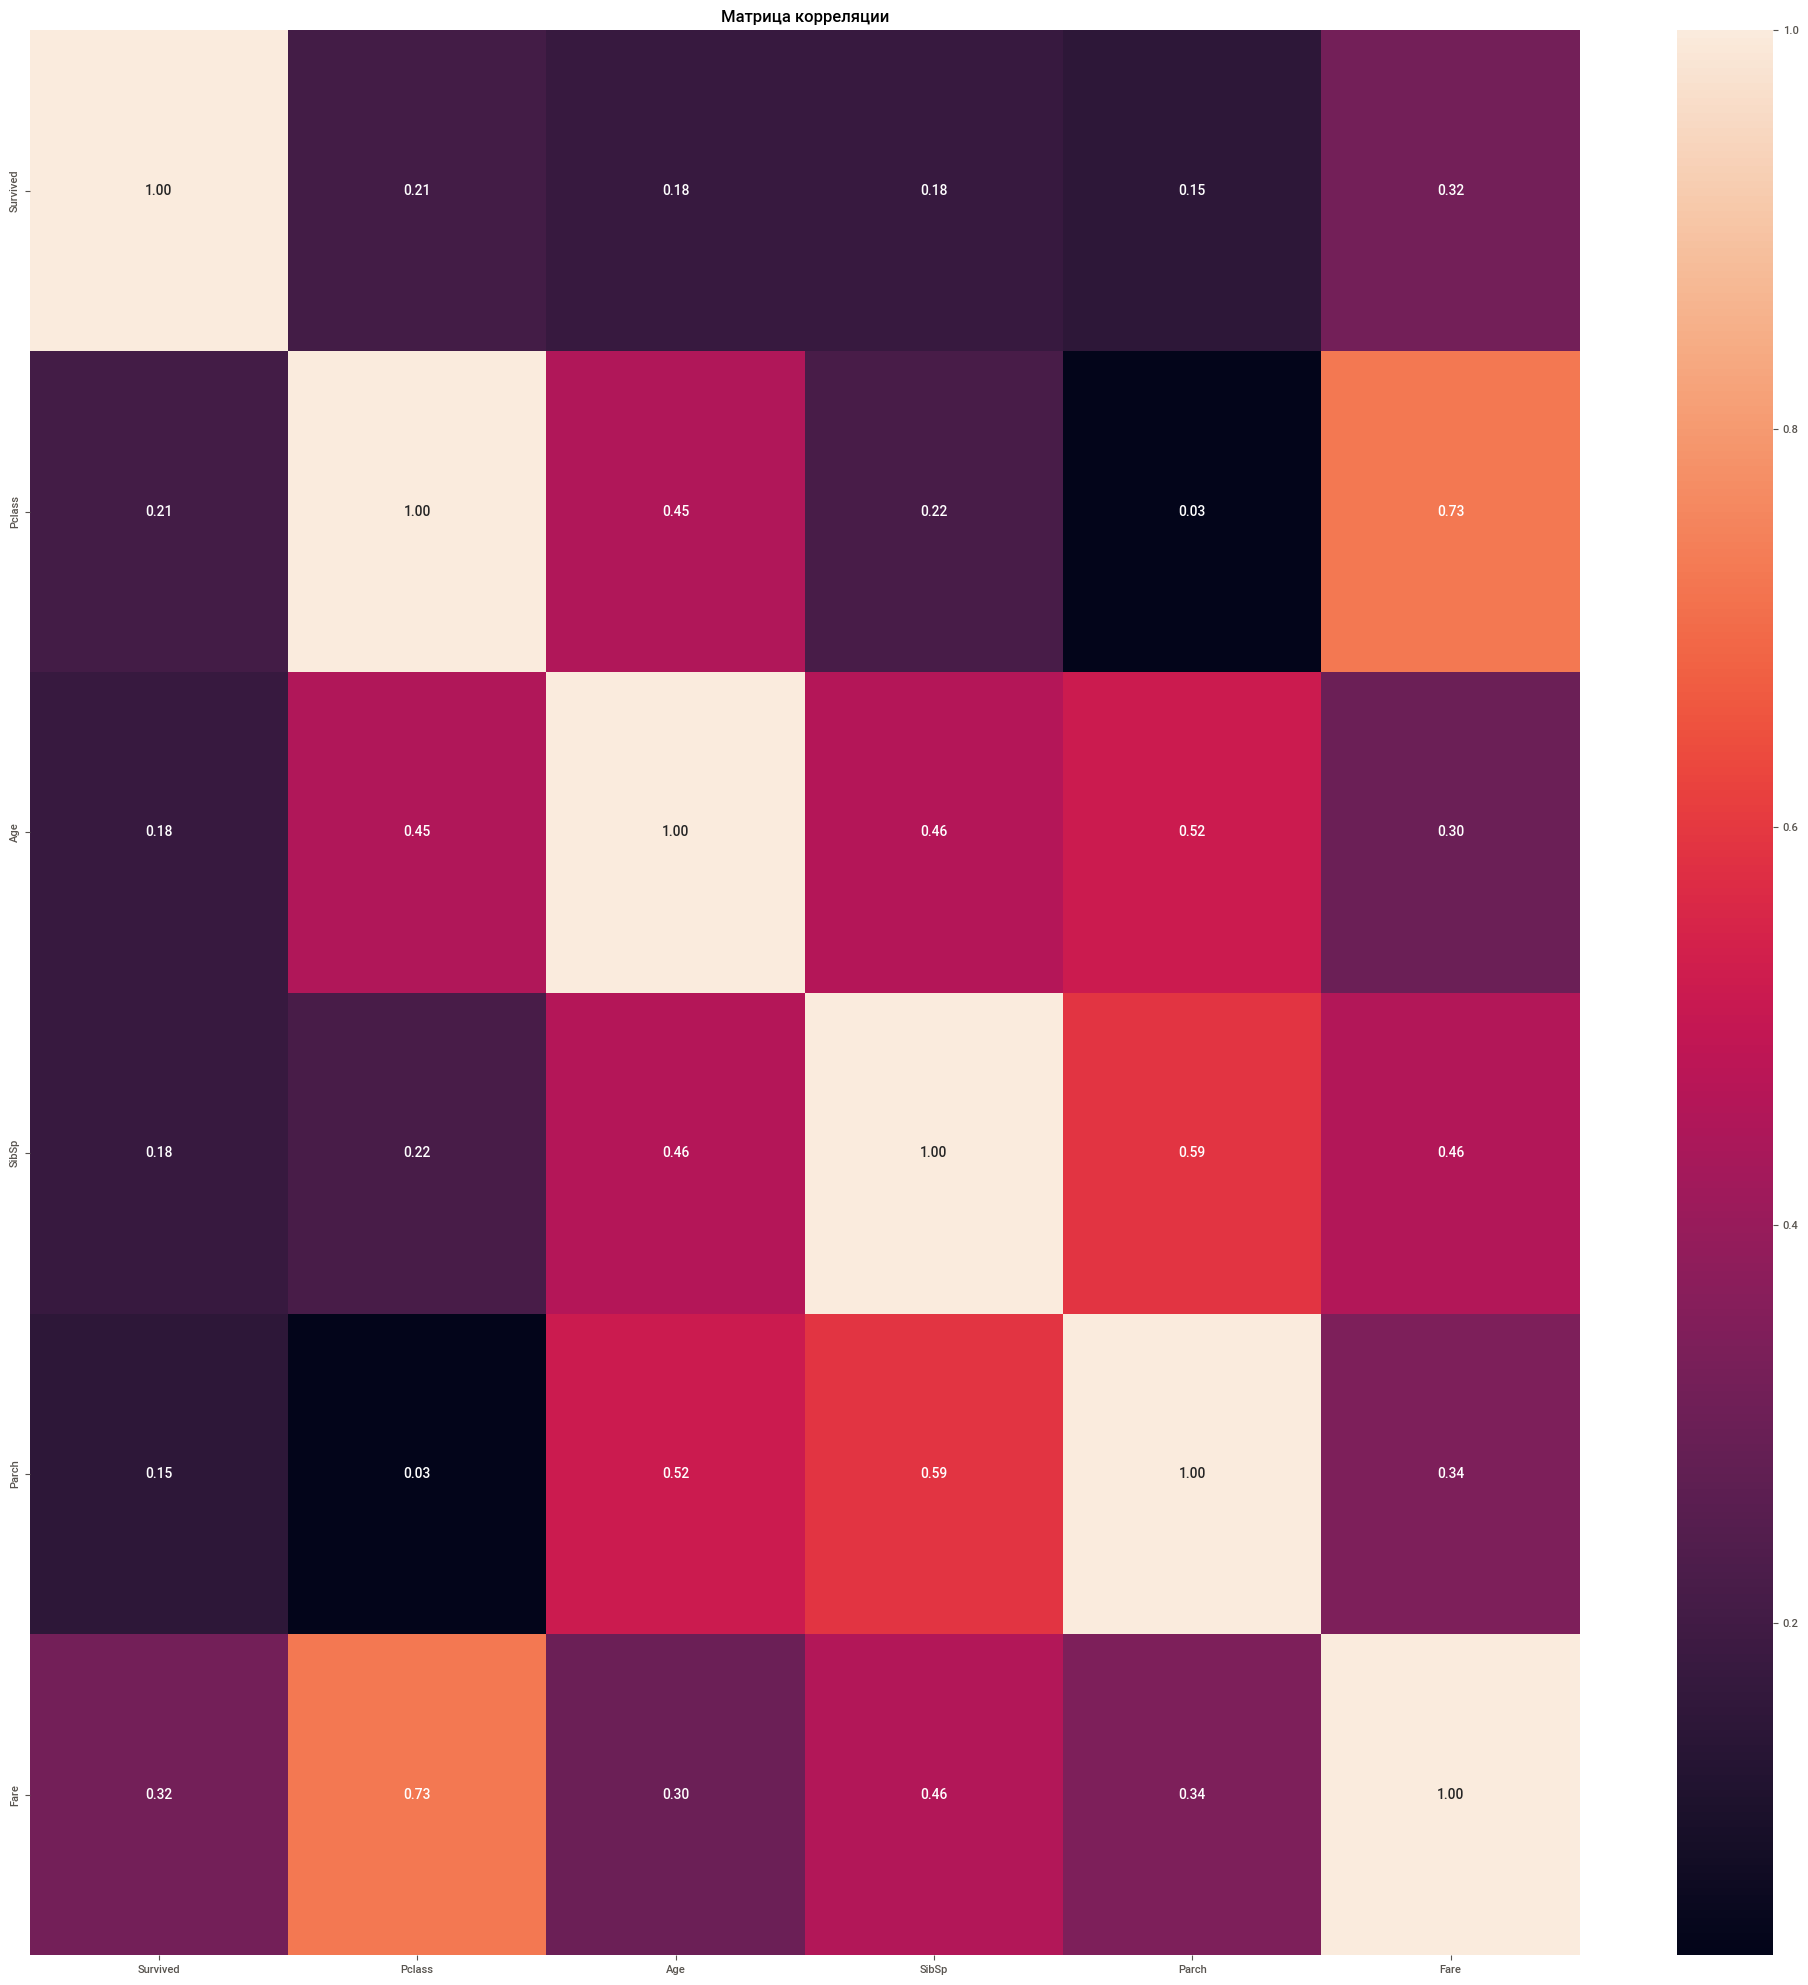

In [40]:
draw_phik_matrix(df, drop_columns=['PassengerId'])